## 타이타닉 생존자 예측

In [1]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
# 사전 라이브러리 설치(XAI용, XAI: 실현가능한 AI) : pip install shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.impute import SimpleImputer    # 결측치를 처리하는데 사용
from sklearn.preprocessing import LabelEncoder    #범주형 데이터를 숫자형 데이터로 변환하는 데 사용
import shap  # feature importance와 유사 (LSTM에 사용)

# 1. 데이터 로드 및 전처리
train_df = pd.read_csv("dataset/train_titanic.csv")
test_df = pd.read_csv("dataset/test_titanic.csv")

# 데이터 확인
print(train_df.head())

# 결측치 확인
print("Train 데이터 결측치 확인:")
print(train_df.isnull().sum())
print("\nTest 데이터 결측치 확인:")
print(test_df.isnull().sum())

# 불필요한 컬럼 제거 (원핫 인코딩 없이도 잘 작동하도록)
train_df = train_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Label Encoding (Sex 컬럼)
le = LabelEncoder()
train_df['Sex'] = le.fit_transform(train_df['Sex'])
test_df['Sex'] = le.transform(test_df['Sex'])  # train 데이터 기준으로 transform
print(train_df.head())

# Embarked 컬럼 처리 (최빈값으로 채우기)
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Label Encoding (Embarked 컬럼)
le_embarked = LabelEncoder()
train_df['Embarked'] = le_embarked.fit_transform(train_df['Embarked'])
test_df['Embarked'] = le_embarked.transform(test_df['Embarked']) # train 데이터 기준으로 transform

# Age 컬럼 결측치 처리 (평균으로 채우기)
imputer = SimpleImputer(strategy='mean')
train_df['Age'] = imputer.fit_transform(train_df[['Age']])
test_df['Age'] = imputer.transform(test_df[['Age']])

# Fare 컬럼 결측치 처리 (평균으로 채우기)
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].mean()) # test 데이터에만 Fare 결측치 존재

# 결측치 재확인
print("Train 데이터 결측치 확인:")
print(train_df.isnull().sum())
print("\nTest 데이터 결측치 확인:")
print(test_df.isnull().sum())

# 전처리 후 데이터 확인
print("전처리 후 데이터 형태:")
print("Train 데이터:", train_df.shape)
print("Test 데이터:", test_df.shape)

# 데이터 컬럼 확인
print("\nTrain 데이터 컬럼:", train_df.columns.tolist())
print("Test 데이터 컬럼:", test_df.columns.tolist())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Tr

In [ ]:
# 스케일링 (MinMaxScaler)
scaler = MinMaxScaler()
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# 피처 수 확인
n_features = X.shape[1]
print(f"피처 수: {n_features}")

X = scaler.fit_transform(X)
test_data = scaler.transform(test_df)

# 특성 이름 저장 (SHAP 시각화에 사용)
feature_names = train_df.drop('Survived', axis=1).columns.tolist()
# 타겟값을 제외한 컬럼들 리스트

# train, validation set 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 데이터 형태 확인
print(f"X_train 형태(reshape 전): {X_train.shape}")
print(f"X_val 형태(reshape 전): {X_val.shape}")
print(f"test_data 형태(reshape 전): {test_data.shape}")

# LSTM 입력을 위한 reshape (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], 1, n_features)
X_val = X_val.reshape(X_val.shape[0], 1, n_features)
test_data = test_data.reshape(test_data.shape[0], 1, n_features)

# reshape 후 형태 확인
print(f"X_train 형태(reshape 후): {X_train.shape}")
print(f"X_val 형태(reshape 후): {X_val.shape}")
print(f"test_data 형태(reshape 후): {test_data.shape}")

피처 수: 7
X_train 형태(reshape 전): (712, 7)
X_val 형태(reshape 전): (179, 7)
test_data 형태(reshape 전): (418, 7)
X_train 형태(reshape 후): (712, 1, 7)
X_val 형태(reshape 후): (179, 1, 7)
test_data 형태(reshape 후): (418, 1, 7)


In [6]:
# 2. LSTM 모델 구축
model = Sequential()
model.add(LSTM(64, input_shape=(1, n_features), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))  # 생존여부에 대한 이진 분류(1, 0)이므로 sigmoid 사용

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # binary_crossentropy : 이진 분류에 사용 (ex. 0, 1 등)

# 모델 구조 확인
model.summary()

c:\NEWTEST\myenv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Early Stopping - verbose=1로 설정하여 진행상황 확인
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,          # 10번의 에폭 동안 개선이 없으면 학습 중단
    restore_best_weights=True,    #  가장 좋은 성능을 보였던 모델의 가중치(weights)를 복원
    verbose=1             # 중단 시 메시지 출력
)

# 3. 모델 훈련 - verbose=1로 설정하여 진행상황 확인
epochs = 100
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1             # 훈련 진행상황 출력
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5765 - loss: 0.6890 - val_accuracy: 0.5866 - val_loss: 0.6757
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6298 - loss: 0.6637 - val_accuracy: 0.5866 - val_loss: 0.6469
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6046 - loss: 0.6370 - val_accuracy: 0.5866 - val_loss: 0.6184
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6093 - loss: 0.6043 - val_accuracy: 0.5866 - val_loss: 0.5956
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6220 - loss: 0.5845 - val_accuracy: 0.6257 - val_loss: 0.5712
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6532 - loss: 0.5953 - val_accuracy: 0.7207 - val_loss: 0.5501
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7309 - loss: 0.5295 - val_accuracy: 0.7598 - val_loss: 0.5315
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7643 - loss: 0.5174 - val_accuracy: 0.7486 - 

In [8]:
# 학습이 몇 번째 에폭에서 멈췄는지 확인
actual_epochs = len(history.history['loss'])
print(f"학습이 {actual_epochs}번째 에폭에서 완료되었습니다.")

# 4. 예측 및 평가
# Validation set 평가
y_pred_val_proba = model.predict(X_val, verbose=0)
y_pred_val = (y_pred_val_proba > 0.5).astype(int)    # 0.5를 기준으로 분류, astype(int) : True는 1로, False는 0

# 테스트 데이터 예측
y_pred_proba = model.predict(test_data, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int)  # 0.5를 기준으로 분류, astype(int) : True는 1로, False는 0

# ROC Curve 및 AUC 계산 (Validation set)
fpr, tpr, thresholds = roc_curve(y_val, y_pred_val_proba)
roc_auc = auc(fpr, tpr)

# Confusion Matrix (Validation set)
cm = confusion_matrix(y_val, y_pred_val)
print("Confusion Matrix (Validation Set):\n", cm)

# Classification Report (Validation set)
print("\nClassification Report (Validation Set):\n", classification_report(y_val, y_pred_val))

학습이 61번째 에폭에서 완료되었습니다.
Confusion Matrix (Validation Set):
 [[93 12]
 [25 49]]

Classification Report (Validation Set):
               precision    recall  f1-score   support

           0       0.79      0.89      0.83       105
           1       0.80      0.66      0.73        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



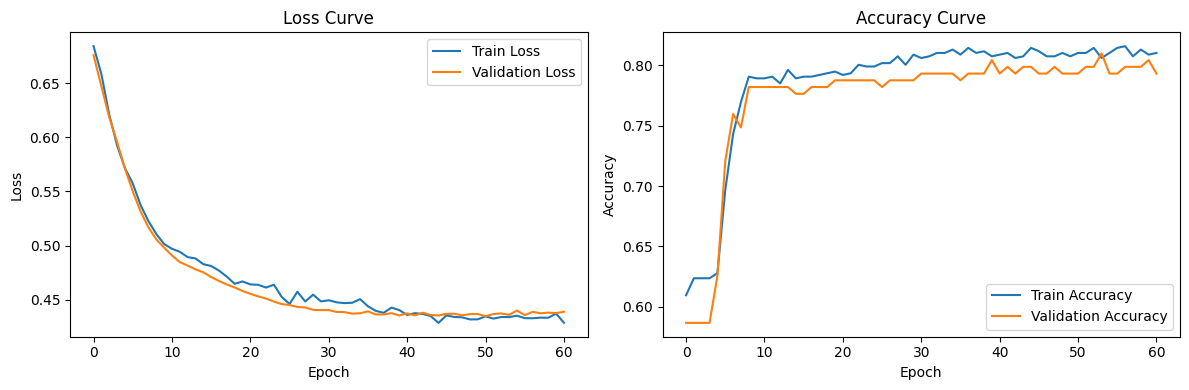

In [9]:
# 5. 결과 시각화 및 통계 분석

# 학습 곡선 시각화 (loss, accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

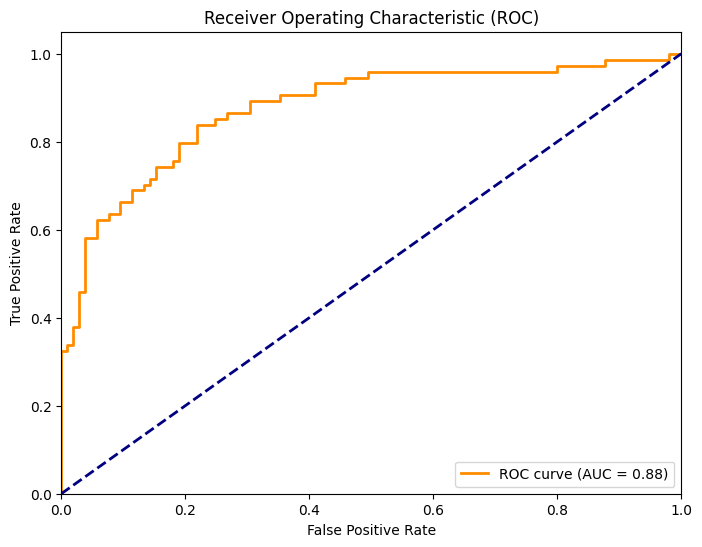

In [10]:
# ROC Curve 시각화 (Validation set)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

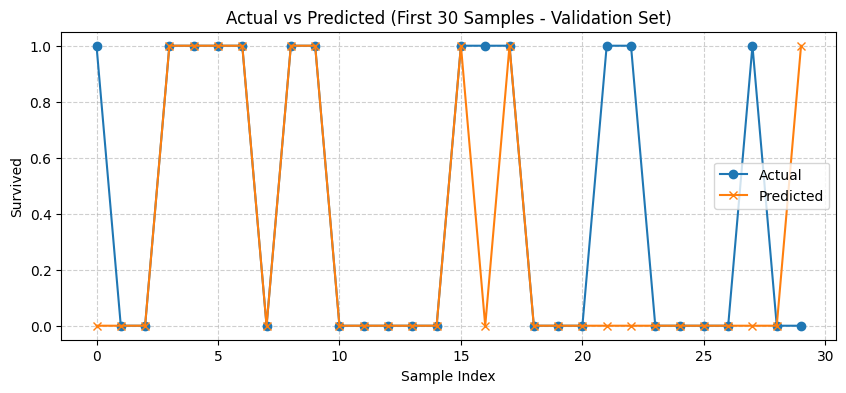

In [11]:
# 실제값 vs 예측값 시각화 (Validation set - 처음 30개 샘플)
plt.figure(figsize=(10, 4))
plt.plot(y_val[:30].values, label='Actual', marker='o')
plt.plot(y_pred_val[:30].flatten(), label='Predicted', marker='x')  # flatten() 추가
plt.title('Actual vs Predicted (First 30 Samples - Validation Set)')
plt.xlabel('Sample Index')
plt.ylabel('Survived')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)  # 그리드 추가
plt.show()

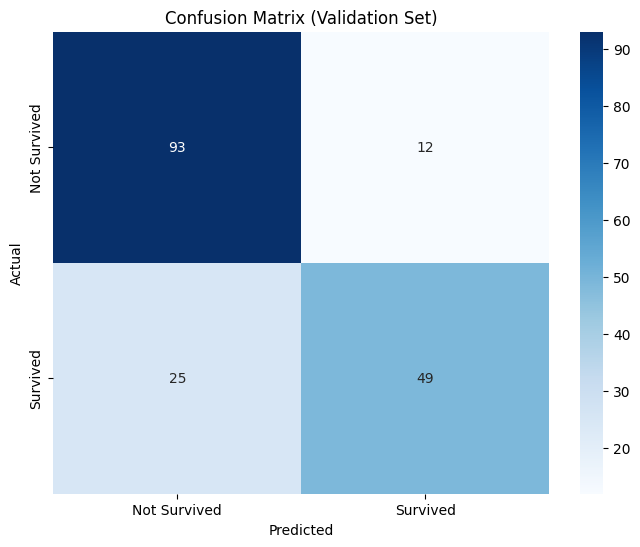

In [12]:
# Confusion Matrix 시각화 (Validation set)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Validation Set)')
plt.show()

In [13]:
# 6. 예측 결과 저장 (개선된 버전)
# test_titanic.csv에서 직접 PassengerId 가져오기
original_test_df = pd.read_csv("dataset/test_titanic.csv")
passenger_ids = original_test_df['PassengerId']

# 예측 결과와 PassengerId를 합쳐 새로운 DataFrame 생성
forecast_results = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': y_pred.flatten()  # flatten()으로 1차원 배열로 변환
})

# 결과 확인
print("예측 결과 (처음 5개 샘플):")
print(forecast_results.head())

예측 결과 (처음 5개 샘플):
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0


In [14]:
# 결과를 CSV 파일로 저장
forecast_results.to_csv('dataset/forecast_titanic.csv', index=False)
print("Survived 예측 결과가 dataset/forecast_titanic.csv 파일로 저장되었습니다.")

# 7. 모델 저장 (선택 사항)
model.save('model/titanic_lstm_model.h5')
print("모델이 'titanic_lstm_model.h5' 파일로 저장되었습니다.")

Survived 예측 결과가 dataset/forecast_titanic.csv 파일로 저장되었습니다.
모델이 'titanic_lstm_model.h5' 파일로 저장되었습니다.


## 생존자 예측 분석 시각화

C:\Users\humna-20\AppData\Local\Temp\ipykernel_4876\1383977473.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_df_viz, palette='viridis')


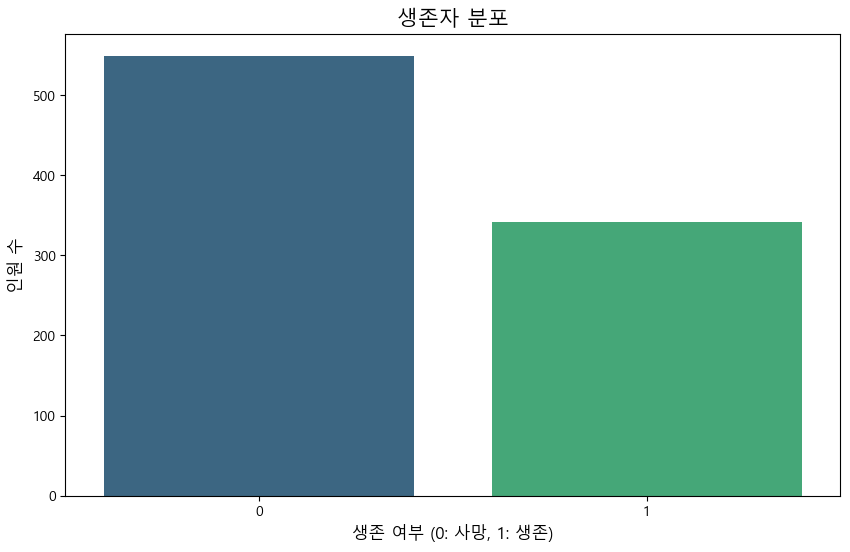

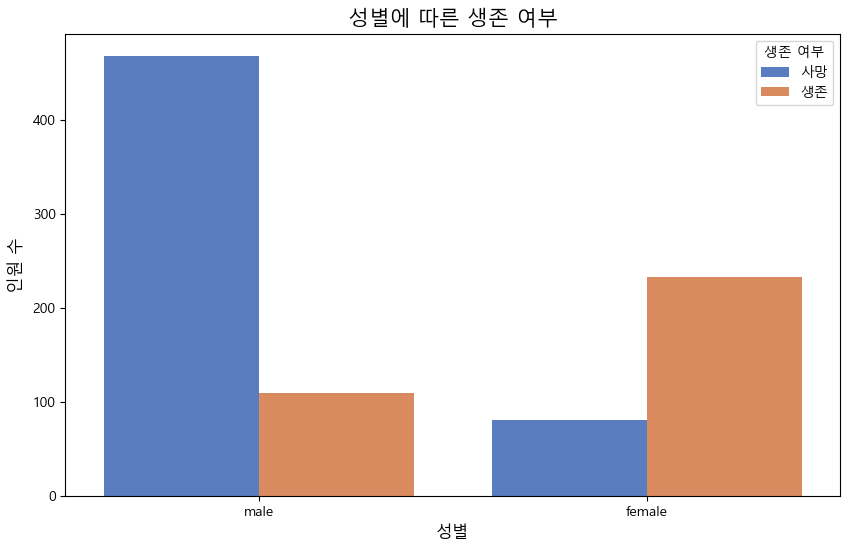

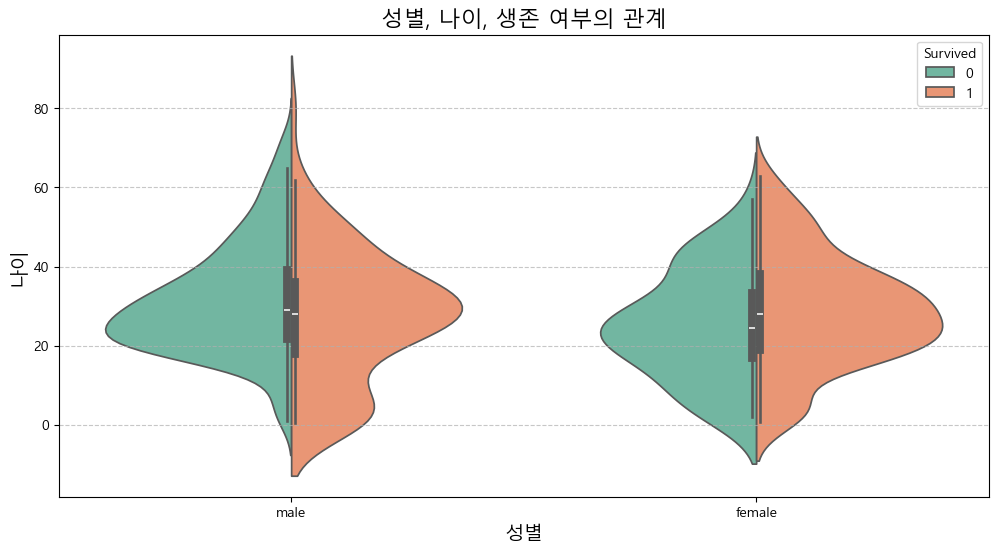

In [15]:
# 원본 데이터를 로드
train_df_viz = pd.read_csv("dataset/train_titanic.csv")

# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

# 생존자 분포 확인
plt.figure(figsize=(10, 6))
sns.countplot(x='Survived', data=train_df_viz, palette='viridis')
plt.title('생존자 분포', fontsize=15)
plt.xlabel('생존 여부 (0: 사망, 1: 생존)', fontsize=12)
plt.ylabel('인원 수', fontsize=12)

# 성별과 생존 관계
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=train_df_viz, palette='muted')
plt.title('성별에 따른 생존 여부', fontsize=15)
plt.xlabel('성별', fontsize=12)
plt.ylabel('인원 수', fontsize=12)
plt.legend(title='생존 여부', labels=['사망', '생존'])

# 나이, 성별, 생존 관계를 보여주는 바이올린 플롯
plt.figure(figsize=(12, 6))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=train_df_viz.dropna(subset=['Age']),
               split=True, palette='Set2')
plt.title('성별, 나이, 생존 여부의 관계', fontsize=16)
plt.xlabel('성별', fontsize=14)
plt.ylabel('나이', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 1200x600 with 0 Axes>

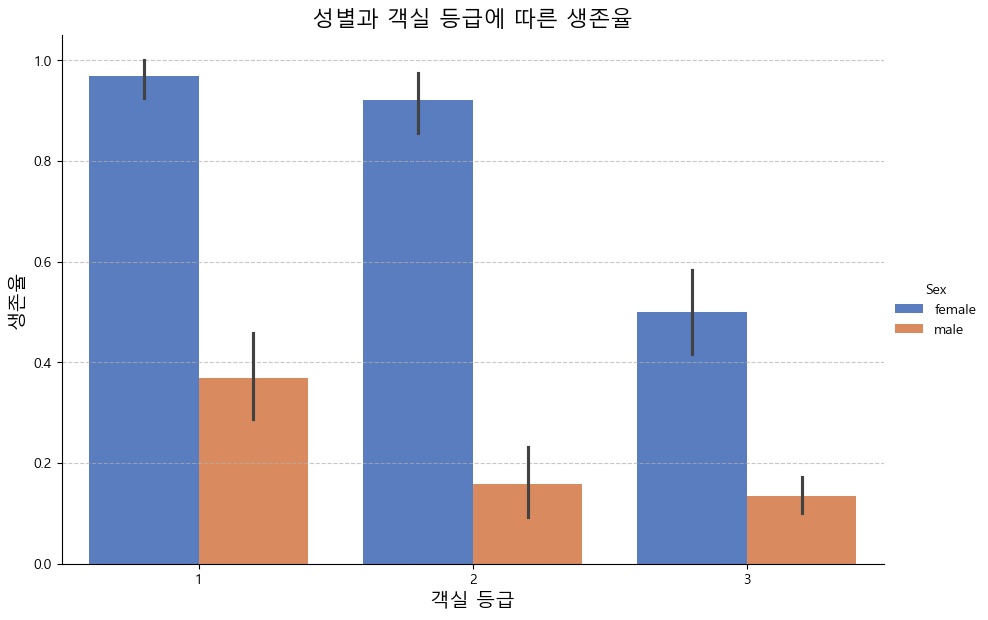

In [16]:
# 성별과 객실 등급에 따른 생존율 (인터랙션 효과) , 검은색 선은 오차
plt.figure(figsize=(12, 6))
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=train_df_viz, height=6, aspect=1.5, palette='muted')
plt.title('성별과 객실 등급에 따른 생존율', fontsize=16)
plt.xlabel('객실 등급', fontsize=14)
plt.ylabel('생존율', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

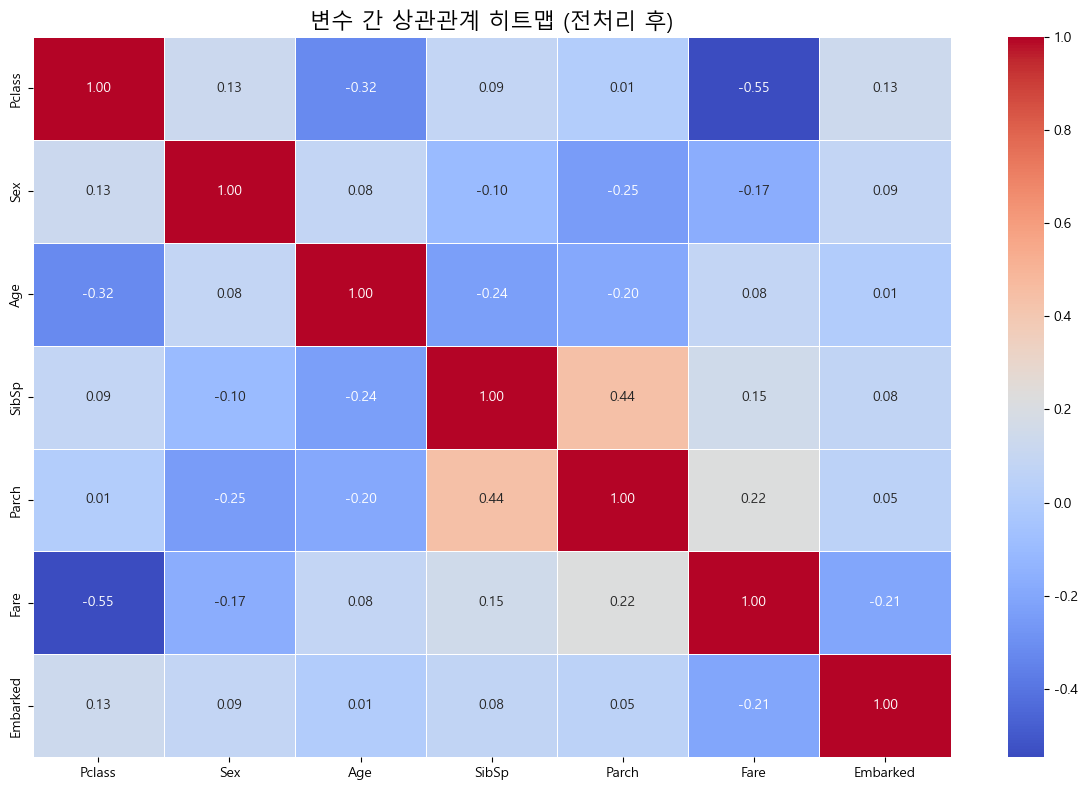

In [17]:
# 히트맵으로 변수 간 상관관계 확인 (전처리된 데이터 사용)
plt.figure(figsize=(12, 8))
X_train_df = pd.DataFrame(X_train.reshape(X_train.shape[0], X_train.shape[2]), columns=train_df.drop('Survived', axis=1).columns)

# 상관계수 행렬 계산
corr_matrix = X_train_df.corr()
# 히트맵 그리기
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('변수 간 상관관계 히트맵 (전처리 후)', fontsize=16)
plt.tight_layout()
plt.show()

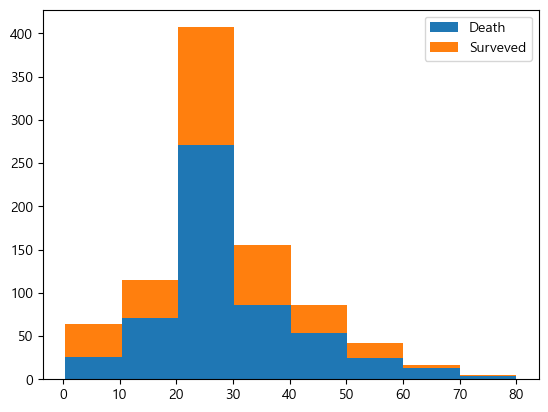

In [18]:
# 연령별 생존률
plt.hist(x=[train_df.Age[train_df.Survived==0], train_df.Age[train_df.Survived==1]], bins=8, histtype='barstacked', label=['Death', 'Surveved'])
plt.legend()

특성 이름: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X_sample 형태: (100, 7)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


  1%|          | 1/100 [00:00<00:23,  4.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


 99%|█████████▉| 99/100 [00:21<00:00,  4.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


100%|██████████| 100/100 [00:22<00:00,  4.50it/s]

SHAP 값 형태: (100, 7)
특성별 중요도: [0.11736147 0.24595076 0.0234426  0.01966994 0.00598545 0.01396918
 0.02490343]


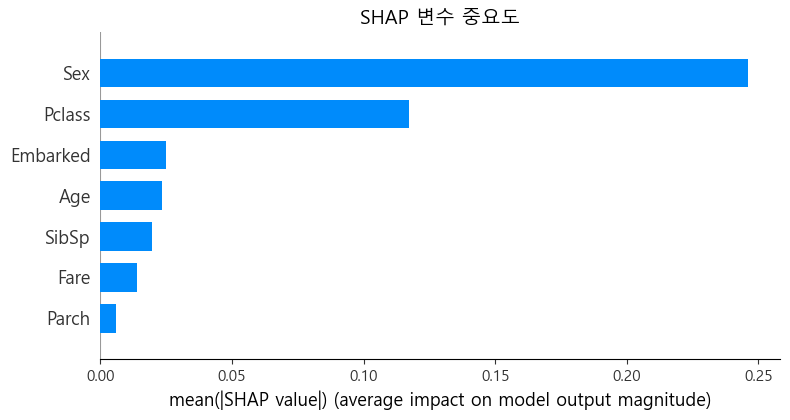

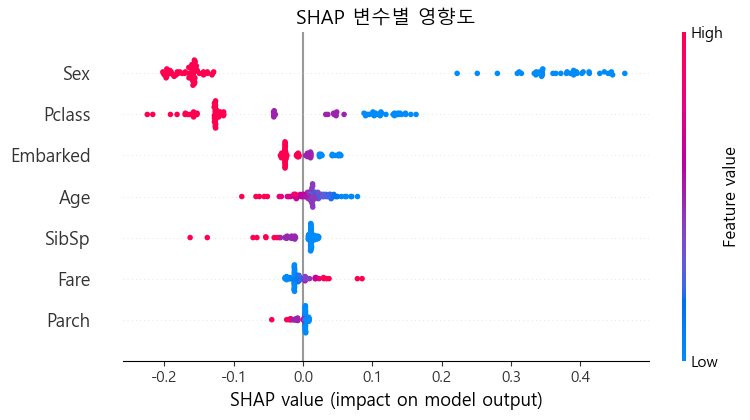

상위 3개 중요 특성: ['Sex', 'Pclass', 'Embarked']


<Figure size 1000x600 with 0 Axes>

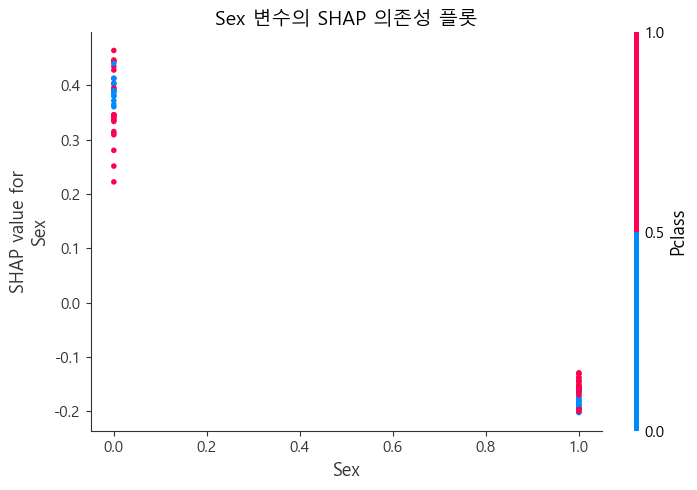

<Figure size 1000x600 with 0 Axes>

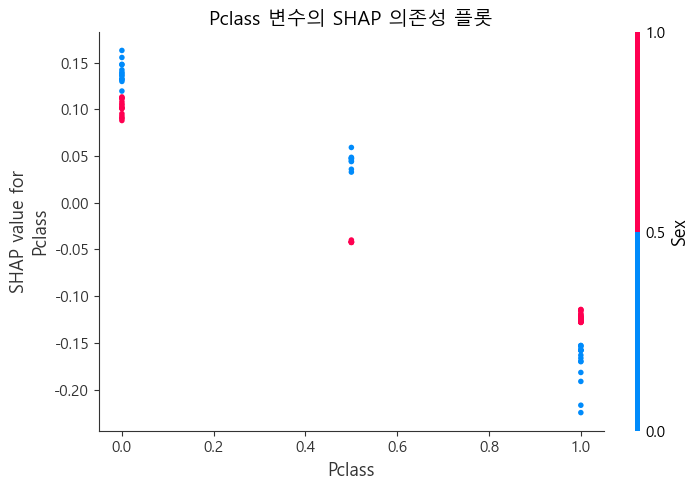

<Figure size 1000x600 with 0 Axes>

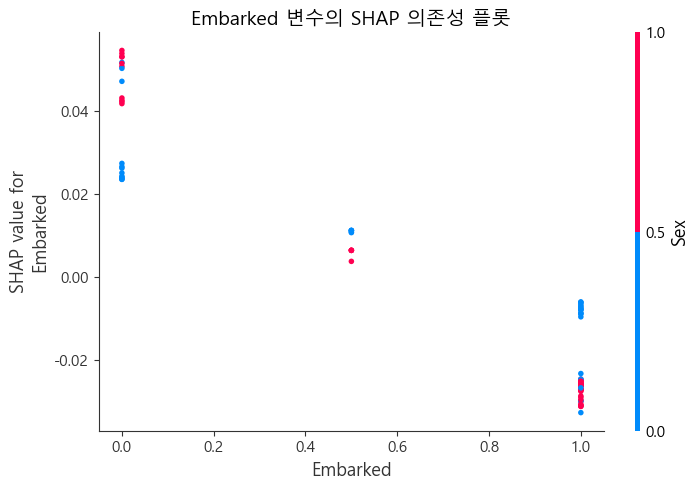

In [19]:
# SHAP 분석을 위한 함수 정의
def f(X):
    # SHAP은 원본 입력 형태를 요구하므로 LSTM 입력 형태로 변환
    X_reshaped = X.reshape(X.shape[0], 1, X.shape[1])
    return model.predict(X_reshaped).flatten()  # flatten()을 추가해 1차원 배열로 변환

# 원본 형태의 데이터로 SHAP 분석 준비 (시각화용 샘플 제한)
X_sample = X_val.reshape(X_val.shape[0], X_val.shape[2])
X_sample = X_sample[:100]  # 계산 시간 단축을 위해 100개 샘플만 사용

# 백그라운드 데이터 생성
background = shap.sample(X_sample, 10)  # 10개의 배경 데이터 샘플링

# 특성 이름 확인 (디버깅용)
print("특성 이름:", feature_names)
print("X_sample 형태:", X_sample.shape)

# SHAP 값 계산 (KernelExplainer 사용)
explainer = shap.KernelExplainer(f, background)
shap_values = explainer.shap_values(X_sample)

# 모든 특성을 강제로 표시하기 위한 설정
max_display = len(feature_names)  # 모든 특성 표시
print("SHAP 값 형태:", np.array(shap_values).shape)
print("특성별 중요도:", np.abs(shap_values).mean(0))

# Title이 포함된 그래프 생성 방식 수정
# 중요도 막대 그래프
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                 plot_type="bar", show=False, max_display=max_display)
plt.title("SHAP 변수 중요도", fontsize=14)
plt.tight_layout()
plt.show()

# 변수별 영향도
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                 show=False, max_display=max_display)
plt.title("SHAP 변수별 영향도", fontsize=14)
plt.tight_layout()
plt.show()

# 개별 변수 의존성 플롯 (상위 3개만)
# 중요도 순으로 특성 인덱스 정렬
importance = np.abs(shap_values).mean(0)
sorted_idx = np.argsort(-importance)
top_features = [feature_names[i] for i in sorted_idx[:3]]  # 상위 3개 특성

print("상위 3개 중요 특성:", top_features)

# 상위 특성에 대해서만 의존성 플롯 생성
for idx in sorted_idx[:3]:
    feature = feature_names[idx]
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(idx, shap_values, X_sample, feature_names=feature_names, show=False)
    plt.title(f"{feature} 변수의 SHAP 의존성 플롯", fontsize=14)
    plt.tight_layout()
    plt.show()